In [208]:
import pandas as pd
import seaborn as sea
from statistics import median, mean
import random

In [209]:
## import data
pepdf = pd.read_csv("ProteasomeDB.csv")
pepdf = pepdf[pepdf["proteasomeSpecies"]=="human"]

In [210]:
pepdf

,sampleID,sampleName,filename,runID,protIsotype,digestTime,proteasomeSpecies,sampleDate,instrument,fragmentation,...,scanNum,rank,ionScore,qValue,productType,spliceType,positions,synErrSR2,charge,PTM
0,25.03.21WA,WA,F032851.csv,1,20S K562,20,human,25.03.21,Fusion,HCD,...,14459,1,20.15,0.00970,PSP,revCis;trans,13_22_4_5;13_22_13_14,no,2,NaN
1,25.03.21WA,WA,F032851.csv,1,20S K562,20,human,25.03.21,Fusion,HCD,...,13067,1,20.19,0.00960,PSP,trans;trans,19_22_14_20;19_21_13_20,no,2,NaN
2,25.03.21WA,WA,F032851.csv,1,20S K562,20,human,25.03.21,Fusion,HCD,...,7000,1,20.20,0.00950,PSP,cis,1_5_13_15,no,2,NaN
3,25.03.21WA,WA,F032851.csv,1,20S K562,20,human,25.03.21,Fusion,HCD,...,5649,1,20.25,0.01400,PSP,cis,2_2_8_23,yes,3,3 Deamidated (NQ)
4,25.03.21WA,WA,F032851.csv,1,20S K562,20,human,25.03.21,Fusion,HCD,...,12523,1,20.39,0.00910,PSP,cis,13_18_20_21,no,2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229348,01.07.19FC6,FC6,TSN97_FC6_QEx1_010719_2_FT_searchResults.csv,2,20S standard,20,human,01.07.19,QE_FT,HCD,...,11453,1,24.16,0.00380,PCP,NaN,11_19,NaN,2,NaN
229349,01.07.19FC6,FC6,TSN97_FC6_QEx1_010719_2_FT_searchResults.csv,2,20S standard,20,human,01.07.19,QE_FT,HCD,...,12545,1,30.89,0.00081,PCP,NaN,11_19,NaN,3,NaN
229350,01.07.19FC6,FC6,TSN97_FC6_QEx1_010719_2_FT_searchResults.csv,2,20S standard,20,human,01.07.19,QE_FT,HCD,...,12959,1,29.64,0.00110,PCP,NaN,11_19,NaN,3,NaN
229351,01.07.19FC6,FC6,TSN97_FC6_QEx1_010719_2_FT_searchResults.csv,2,20S standard,20,human,01.07.19,QE_FT,HCD,...,11045,1,30.66,0.00086,PCP,NaN,11_19,NaN,3,NaN


In [211]:
pcp = pd.DataFrame()
psp = pd.DataFrame()

pcp["pepSeq"] = pepdf['pepSeq'][pepdf['productType']=="PCP"]
psp['pepSeq'] = pepdf['pepSeq'][pepdf['productType']=="PSP"]
psp = psp[pepdf["spliceType"]=="cis"]

pcp["prot"] = pepdf['substrateSeq'][pepdf['productType']=="PCP"]
print(pcp)
psp['prot'] = pepdf['substrateSeq'][pepdf['productType']=="PSP"]
print(psp)

                   pepSeq                      prot
9       SRQLRTKAWNRQLYPEW   VSRQLRTKAWNRQLYPEWTEAQR
13               TKAWNRQL   VSRQLRTKAWNRQLYPEWTEAQR
18        QLRTKAWNRQLYPEW   VSRQLRTKAWNRQLYPEWTEAQR
38                 NRQLYP   VSRQLRTKAWNRQLYPEWTEAQR
45         VSRQLRTKAWNRQL   VSRQLRTKAWNRQLYPEWTEAQR
...                   ...                       ...
229348          RWQFPAHYR  LSAVLGLLLLRWQFPAHYRRLRHA
229349          RWQFPAHYR  LSAVLGLLLLRWQFPAHYRRLRHA
229350          RWQFPAHYR  LSAVLGLLLLRWQFPAHYRRLRHA
229351          RWQFPAHYR  LSAVLGLLLLRWQFPAHYRRLRHA
229352          RWQFPAHYR  LSAVLGLLLLRWQFPAHYRRLRHA

[188670 rows x 2 columns]
                   pepSeq                      prot
2                VSRQLQLY   VSRQLRTKAWNRQLYPEWTEAQR
3       SKAWNRQLYPEWTEAQR   VSRQLRTKAWNRQLYPEWTEAQR
4                QLYPEWEA   VSRQLRTKAWNRQLYPEWTEAQR
7          SAWNRQLYPEWTEA   VSRQLRTKAWNRQLYPEWTEAQR
11                KQLYPEW   VSRQLRTKAWNRQLYPEWTEAQR
...                   ...            

/tmp/ipykernel_156045/3198268730.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  psp = psp[pepdf["spliceType"]=="cis"]


In [212]:
pcp['pepLength'] = pcp['pepSeq'].str.len()
psp['pepLength'] = psp['pepSeq'].str.len()

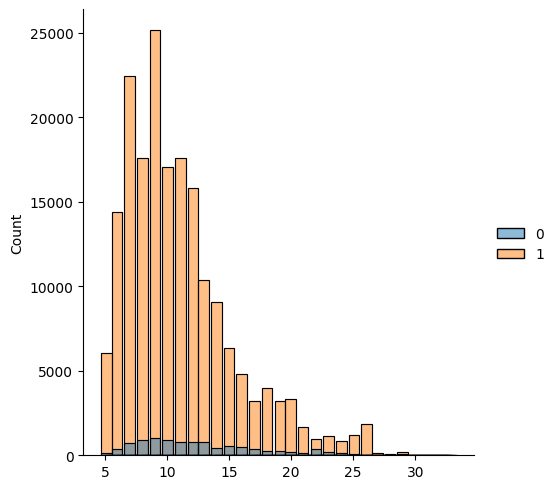

In [213]:
listlendata = [list(psp['pepLength']), list(pcp['pepLength'])]
pl = sea.displot(listlendata, shrink=5)
##### 0 — PSP, 1 — PCP
# filtering length
pcpf = pcp[pcp['pepLength'].isin([9, 10, 11, 12])]
pspf = psp[psp['pepLength'].isin([9, 10, 11, 12])]

In [214]:
print("PCP median:", median(pcp['pepLength']), "PCP mean:", mean(pcp['pepLength']))
print("PSP median:", median(psp['pepLength']), "PSP mean:", mean(psp['pepLength']))

PCP median: 10.0 PCP mean: 11.018301796788043
PSP median: 12.0 PSP mean: 12.909986075193952


In [215]:
sample_size = 500
listseqdata = [list(pcpf['pepSeq']), list(pspf['pepSeq'])]
tt = ""
for i in range(len(listseqdata)):
    ft = str(i)+"::\n\n"
    if len(listseqdata[i])>sample_size:
        cho = random.sample(listseqdata[i], sample_size)
    else:
        cho = listseqdata[i]
    tt += ft + "\n".join(cho) + "\n\n"

print(tt)
file = open("peptideSamples2023.txt", "w")
file.write(tt)
file.close()

0::

CFFTFPLGGKKQ
PTVFDNYSA
TLKLMEVPVL
RDSALGAAAAAT
WDLNTPAFEWYY
HLGSQPGKHL
HPQQFLYAGS
LSRAGAVAF
HPQQFLYAG
LGELLLKRLLL
VSRQLRTKAW
RQSLLEYKA
GRLADKSVLVC
NFTALSYPPGYH
VSVSQLRALD
QNLPSTLLQD
HALESWRQLV
LPPGVQVGDLL
HLGSQPGKHL
QLYPEWTEA
ALESWRQLV
TLQRAALKFL
LGELLLKRLLLN
QNLPSTLLQD
TSPDLPAEVQM
DLLRNEQTMG
AGTAFLQTQQL
ALESWRQLVE
LADKSVLVC
YPHFMPTNL
SQTDQMVFN
LGSQPGKHLCVY
SQTDQMVFNT
KAAVTLQRA
LWYRPPELLL
TLENVKAKLQD
KDALGEGKVTLR
VKTLTGKTL
VKLGDFGLATVK
GLENLCHLHLE
WMSALPDTT
HCGDSRAVLSR
AGETLNALKG
ALESWRQLVE
RLADKSVLVC
NFTALSYPPGYH
LTSLVRRATL
EYLPTVFDNY
QLYPEWTEA
WNRQLYPEW
VVVGAGGVGKSA
AAMADTFLEHM
AHSSSAFTL
ALESWRQLVE
ALESWRQLV
PAFEWYYQS
SHTSPDLPAE
LQCLHAKRH
NLPSTLLQD
CFFTFPLGGKKQ
FFTFPLGGKKQ
QTMGSLRQV
VGPSGSGKSTVL
ALESWRQLV
LESWRQLVE
SAFTLMDQV
PHFMPTNLG
VGPSGSGKSTVL
SVSVSQLRA
AFPGEYLPTVFD
RDPHSGHFV
AGAVAFSTED
KLGDFGLATV
DMYPHFMPTNL
ASQTDQMVFN
TTNAFPGEY
ALESWRQLVE
KARDPHSGHFV
ALESWRQLVE
SVSQLRALD
LESWRQLVE
YFDCFSESALRK
GEYLPTVFD
HLGSQPGKHL
GPSEKRVWMS
FSLRPRSLTGL
DSALGAAAAA
LGELLLKRLLL
TVEERVLNEEY
A

In [ ]:
sample_size = 500
listlendataf = [list(pcpf["pepLength"]), list(pspf["pepLength"])]
n = 0
listseqdata = [[],[]]
for i in (pcpf['prot'].keys()):
    pepL = listlendataf[0][n]
    n+=1
    protL = len(pcpf["prot"][i])
    ind = random.sample(range(protL - int(pepL) + 1), 1)
    listseqdata[0].append(pcpf["prot"][i][ind[0]:int(ind[0]+int(pepL))])
n = 0
for i in (pspf['prot'].keys()):
    pepL = listlendataf[1][n]
    n+=1
    protL = len(pspf["prot"][i])
    l1 = random.sample(range(pepL-1), 1)[0]+1
    l2 = pepL - l1
    ind1 = random.sample(range(protL - l1 + 1), 1)[0]
    ind2 = random.sample(range(protL - l2 - l1 + 1), 1)[0]
    pp1 = pspf["prot"][i][ind1:(ind1+l1)]
    left = pspf["prot"][i][:ind1]+pspf["prot"][i][ind1+l1:]
    pp2 = (left[ind2:(ind2+l2)])
    listseqdata[1].append(pp1+pp2)


tt = ""
for i in range(len(listseqdata)):
    ft = str(i)+"::\n\n"
    if len(listseqdata[i])>sample_size:
        cho = random.sample(listseqdata[i], sample_size)
    else:
        cho = listseqdata[i]
    tt += ft + "\n".join(cho) + "\n\n"

print(tt)
file = open("protSamples2023.txt", "w")
file.write(tt)
file.close()